# 糖尿病预测与风险因素分析

**数据集**:Pima Indians Diabetes Database(皮马印第安人糖尿病数据集,768 条记录)

**目标**:基于体检指标预测个体是否患有糖尿病,并找出最关键的风险因素。

**分析流程**:
1. 数据加载与概览
2. 数据质量检查(识别"伪 0"缺失值)
3. 数据清洗与缺失值处理
4. 探索性数据分析(EDA)
5. 关键风险因素分析(重点)
---

## 1. 导入工具库与环境和字体设置

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib import font_manager as fm
import os
import warnings
warnings.filterwarnings("ignore")``

# 中文显示设置:先按文件路径加载字体,再用 rcParams 指定
for fp in [r"C:\Windows\Fonts\simhei.ttf", r"C:\Windows\Fonts\msyh.ttc"]:
    if os.path.exists(fp):
        fm.fontManager.addfont(fp)
plt.rcParams["font.sans-serif"] = ["SimHei", "Microsoft YaHei"]
plt.rcParams["axes.unicode_minus"] = False
plt.rcParams["figure.dpi"] = 110
sns.set_style("whitegrid", {"font.sans-serif": ["SimHei", "Microsoft YaHei"]})
print("环境就绪,中文字体:", plt.rcParams["font.sans-serif"][0])

环境就绪,中文字体: SimHei


## 2. 数据加载与概览

In [2]:
df = pd.read_csv('diabetes.csv')
print('数据规模:', df.shape[0], '行 x', df.shape[1], '列')
df.head(10)

数据规模: 768 行 x 9 列


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1
5,5,116,74,0,0,25.6,0.201,30,0
6,3,78,50,32,88,31.0,0.248,26,1
7,10,115,0,0,0,35.3,0.134,29,0
8,2,197,70,45,543,30.5,0.158,53,1
9,8,125,96,0,0,0.0,0.232,54,1


In [4]:
trans = {
    'Pregnancies': '怀孕次数',
    'Glucose': '血糖浓度(口服葡萄糖耐量测试)',
    'BloodPressure': '舒张压 (mm Hg)',
    'SkinThickness': '三头肌皮褶厚度 (mm)',
    'Insulin': '2小时血清胰岛素 (mu U/ml)',
    'BMI': '身体质量指数',
    'DiabetesPedigreeFunction': '糖尿病家族遗传函数',
    'Age': '年龄(岁)',
    'Outcome': '是否患糖尿病(1=是, 0=否)'
}
pd.DataFrame(list(trans.items()), columns=['字段', '含义'])

,字段,含义
0,Pregnancies,怀孕次数
1,Glucose,血糖浓度(口服葡萄糖耐量测试)
2,BloodPressure,舒张压 (mm Hg)
3,SkinThickness,三头肌皮褶厚度 (mm)
4,Insulin,2小时血清胰岛素 (mu U/ml)
5,BMI,身体质量指数
6,DiabetesPedigreeFunction,糖尿病家族遗传函数
7,Age,年龄(岁)
8,Outcome,"是否患糖尿病(1=是, 0=否)"


In [3]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
Pregnancies,768.0,3.845052,3.369578,0.000,1.00000,3.0000,6.00000,17.00
Glucose,768.0,120.894531,31.972618,0.000,99.00000,117.0000,140.25000,199.00
BloodPressure,768.0,69.105469,19.355807,0.000,62.00000,72.0000,80.00000,122.00
SkinThickness,768.0,20.536458,15.952218,0.000,0.00000,23.0000,32.00000,99.00
Insulin,768.0,79.799479,115.244002,0.000,0.00000,30.5000,127.25000,846.00
BMI,768.0,31.992578,7.884160,0.000,27.30000,32.0000,36.60000,67.10
DiabetesPedigreeFunction,768.0,0.471876,0.331329,0.078,0.24375,0.3725,0.62625,2.42
Age,768.0,33.240885,11.760232,21.000,24.00000,29.0000,41.00000,81.00
Outcome,768.0,0.348958,0.476951,0.000,0.00000,0.0000,1.00000,1.00


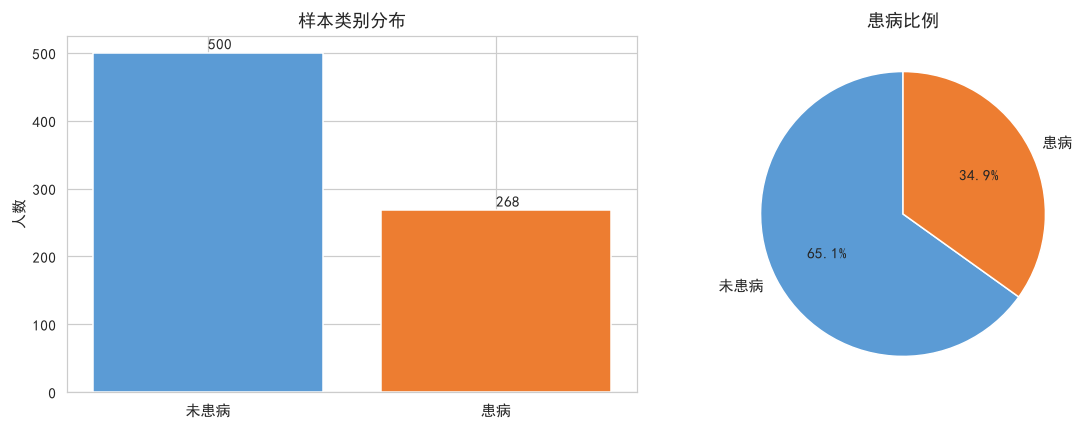

类别比例约为 500:268 (≈1.87:1),存在轻度类别不平衡,并且患病比例远超过普通人群


In [7]:
# 目标变量分布
counts = df['Outcome'].value_counts()
fig, ax = plt.subplots(1, 2, figsize=(11, 4))
ax[0].bar(['未患病', '患病'], counts.values, color=['#5B9BD5', '#ED7D31'])
ax[0].set_title('样本类别分布')
ax[0].set_ylabel('人数')
for i, v in enumerate(counts.values):
    ax[0].text(i, v+5, str(v))
#v+5防止溢出图标
ax[1].pie(counts.values, labels=['未患病', '患病'], autopct='%1.1f%%',
          colors=['#5B9BD5', '#ED7D31'], startangle=90)
ax[1].set_title('患病比例')
plt.tight_layout()
plt.show()
print(f'类别比例约为 {counts[0]}:{counts[1]} (≈1.87:1),存在轻度类别不平衡,并且患病比例远超过普通人群')

## 3. 数据质量检查:识别"伪 0"缺失值

这个数据集有一个**经典陷阱**:血糖、血压、BMI 等指标在医学上**不可能为 0**,
数据中的 0 实际上是**缺失值被填充成了 0**。如果直接拿来训练,会严重拉低模型表现。

In [5]:
# 统计本应非零的列中 0 值的数量
zero_cols = ['Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI']
zero_stat = pd.DataFrame({
    '0值数量': [(df[c] == 0).sum() for c in zero_cols],
    '占比(%)': [round((df[c] == 0).mean()*100, 1) for c in zero_cols]
}, index=zero_cols)
print('真正的 NaN 缺失值数量:', df.isnull().sum().sum())
print('\n本应非零的列中的"伪缺失"(0值)统计:')
zero_stat

真正的 NaN 缺失值数量: 0

本应非零的列中的"伪缺失"(0值)统计:


,0值数量,占比(%)
Glucose,5,0.7
BloodPressure,35,4.6
SkinThickness,227,29.6
Insulin,374,48.7
BMI,11,1.4


findfont: Failed to find font weight bold, now using 400.


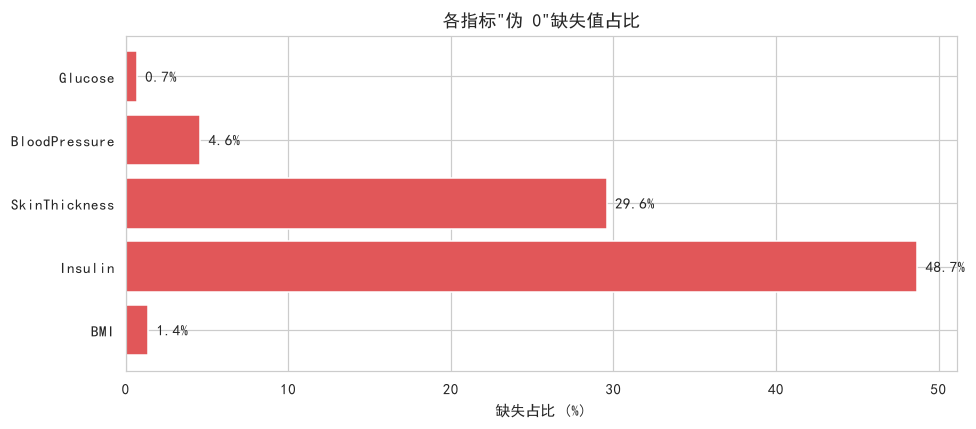

结论:Insulin 和 SkinThickness 缺失最严重,需要处理而非直接删除


In [6]:
# 可视化"伪缺失"占比
fig, ax = plt.subplots(figsize=(9, 4))
bars = ax.barh(zero_stat.index, zero_stat['占比(%)'], color='#E15759')
ax.set_xlabel('缺失占比 (%)')
ax.set_title('各指标"伪 0"缺失值占比', fontweight='bold')
for bar, v in zip(bars, zero_stat['占比(%)']):
    ax.text(v+0.5, bar.get_y()+bar.get_height()/2, f'{v}%', va='center')
ax.invert_yaxis()
plt.tight_layout()
plt.show()
print('结论:Insulin 和 SkinThickness 缺失最严重,需要处理而非直接删除')

## 4. 数据清洗与缺失值处理

策略:将这些列的 0 替换为 NaN,再用**按患病分组的中位数**填充。
按分组填充比用全局中位数更合理——患病与未患病人群的生理指标分布本就不同。

In [7]:
df_clean = df.copy()
# 把伪缺失的 0 替换为 NaN
for c in zero_cols:
    df_clean[c] = df_clean[c].mask(df_clean[c] == 0)

# 按 Outcome 分组,用中位数填充
for c in zero_cols:
    df_clean[c] = df_clean.groupby('Outcome')[c].transform(lambda s: s.fillna(s.median()))

print('清洗后剩余缺失值:', df_clean.isnull().sum().sum())
print('清洗完成,所有伪缺失已用分组中位数填充')
df_clean.describe().T[['mean', 'min', 'max']]
df_clean.to_csv("clean_data.csv",index=False)

清洗后剩余缺失值: 0
清洗完成,所有伪缺失已用分组中位数填充


## 5. 探索性数据分析 (EDA)

findfont: Failed to find font weight bold, now using 400.


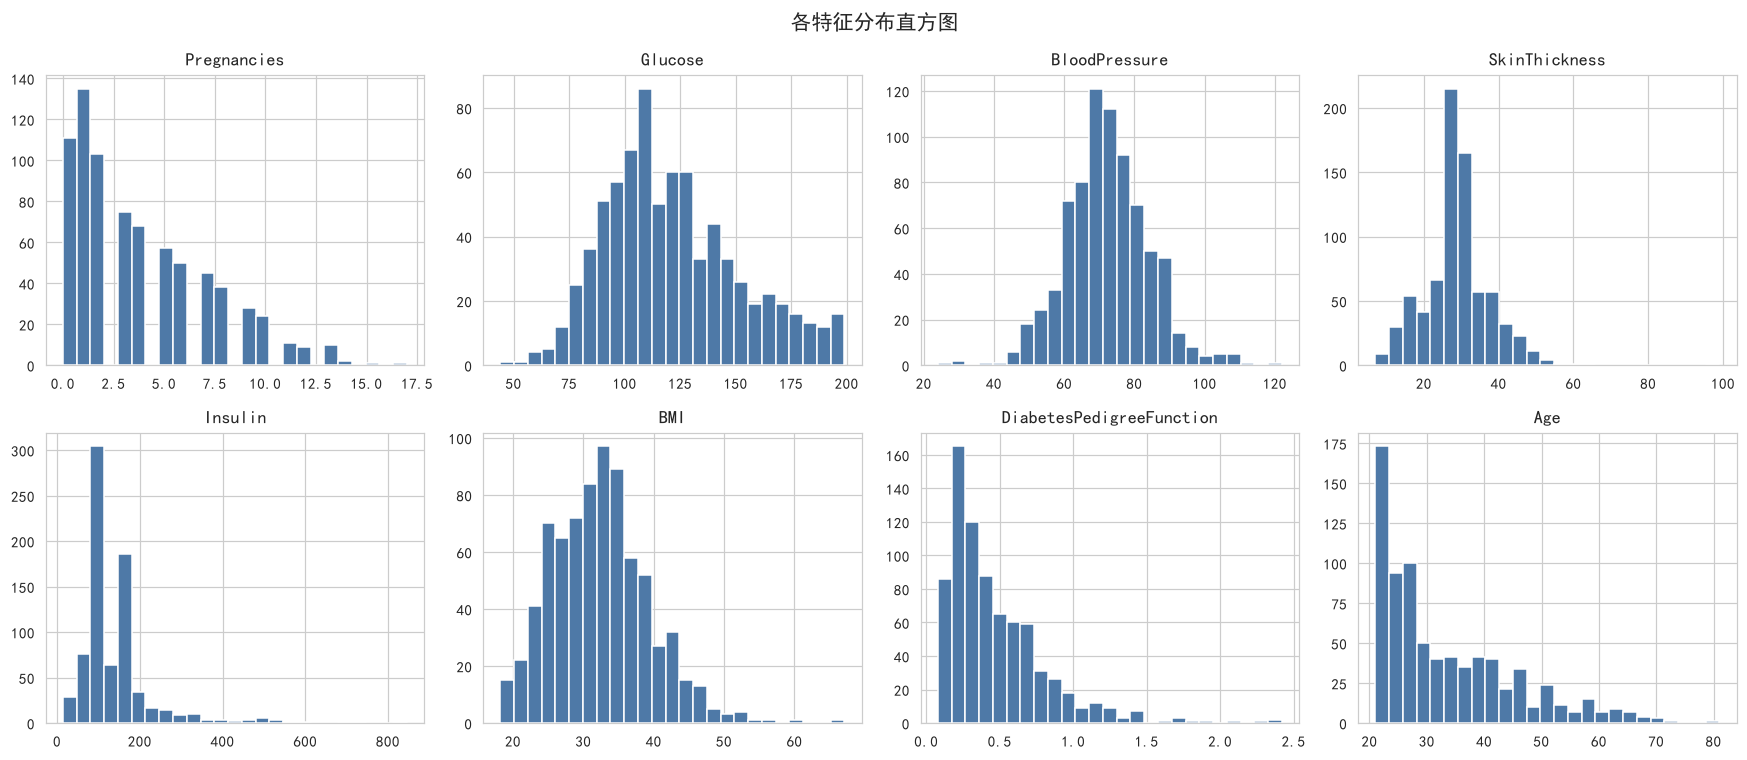

In [8]:
# 各特征分布直方图
fig, axes = plt.subplots(2, 4, figsize=(16, 7))
feat = [c for c in df_clean.columns if c != 'Outcome']
for i, col in enumerate(feat):
    ax = axes[i//4, i%4]
    ax.hist(df_clean[col], bins=25, color='#4E79A7', edgecolor='white')
    ax.set_title(col)
plt.suptitle('各特征分布直方图', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()